# Lilylet NotaGen model validation — Llama backbone

Same as `lilylet_notagen_model_validation.ipynb` but for the **Llama-backbone** variant: loads the `LilyletPatchy` dataset and the `LilyletNotaGen` / `LilyletNotaGenLoss` model built with `model.args.base_type: llama` (RoPE positions, GQA-capable), runs a forward pass, checks loss & accuracy, and runs a few training steps to confirm the loss decreases.

Config: `configs/lilylet-notagen-llama.yaml`  ·  Data: `~/data/lilylet/patches/notagenx-from-abc.lilylet-notagen.pt`

In [2]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

DATA_DIR = str(Path.home() / 'data' / 'lilylet' / 'patches')
CONFIG = str(REPO_ROOT / 'configs' / 'lilylet-notagen-llama.yaml')
print('repo:', REPO_ROOT)
print('data dir:', DATA_DIR)

repo: /home/camus/work/deep-starry
data dir: /home/camus/data/lilylet/patches


In [3]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
# the small local sample artifact (patch_length 2048); the llama config's 1024 only
# bounds the model's max positions, which is fine for these short val samples.
config['data.root'] = 'notagenx-from-abc.lilylet-notagen.pt'
config['data.batch_size'] = 2
config['trainer.device'] = 'cpu'

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
print('input_patches:', tuple(batch['input_patches'].shape), batch['input_patches'].dtype)
print('input_masks:  ', tuple(batch['input_masks'].shape), batch['input_masks'].dtype)
print('max token id:', int(batch['input_patches'].max()), '/ token_vocab_size', config['model.args.token_vocab_size'])
print('real patches per item:', batch['input_masks'].sum(dim=1).tolist())

train items: 194 val items: 21
batch keys: ['input_patches', 'input_masks']
input_patches: (2, 509, 16) torch.int64
input_masks:   (2, 509) torch.int64
max token id: 255 / token_vocab_size 256
real patches per item: [323, 509]


In [4]:
# Inference model (deducer) and Loss model (training wrapper)
deducer = loadModel(config['model'])
model = loadModel(config['model'], postfix='Loss')

n_params = sum(p.numel() for p in model.deducer.parameters())
print('LilyletNotaGen params: %.2fM' % (n_params / 2**20))
print('base_type:', model.deducer.base_type)
print('patch base:', type(model.deducer.patch_level_decoder.base).__name__,
      '| char base:', type(model.deducer.token_level_decoder.base).__name__)
print('patch-level layers:', model.deducer.patch_level_decoder.base.config.num_hidden_layers)
print('char-level layers: ', model.deducer.token_level_decoder.base.config.num_hidden_layers)
# hidden size is base-agnostic: GPT2 stores n_embd, Llama stores hidden_size
pc = model.deducer.patch_level_decoder.base.config
print('hidden size:', getattr(pc, 'n_embd', None) or pc.hidden_size)

LilyletNotaGen params: 46.26M
base_type: llama
patch base: LlamaModel | char base: LlamaForCausalLM
patch-level layers: 8
char-level layers:  3
hidden size: 512


In [5]:
# Single forward pass: loss (scalar Tensor) + metric (dict)
model.train()
loss, metric = model(batch)
print('loss:', loss.item())
print('metric:', metric)
assert loss.requires_grad and loss.dim() == 0

# inspectRun gives a detail dict (used by validators)
model.eval()
with torch.no_grad():
    insp = model.inspectRun(batch)
print('inspect:', {k: (v if not torch.is_tensor(v) else tuple(v.shape)) for k, v in insp.items()})

loss: 5.727048873901367
metric: {'acc': 0.003082885639742017}
inspect: {'loss': 5.727048873901367, 'acc': 0.003082885639742017, 'logits': (830, 17, 256), 'target_patches': (830, 16), 'n_patches': 830}


In [6]:
# A few training steps on one batch should drive the loss down.
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(20):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['acc']))
    if step % 5 == 0 or step == 19:
        print(f'step {step:02d}  loss={loss.item():.4f}  acc={metric["acc"]:.4f}')

print('\nloss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('acc  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease'

step 00  loss=5.7270  acc=0.0031
step 05  loss=2.5469  acc=0.3796
step 10  loss=1.5699  acc=0.5919
step 15  loss=1.2710  acc=0.6302
step 19  loss=1.1657  acc=0.6436

loss start -> end: 5.727 -> 1.1657
acc  start -> end: 0.0031 -> 0.6436


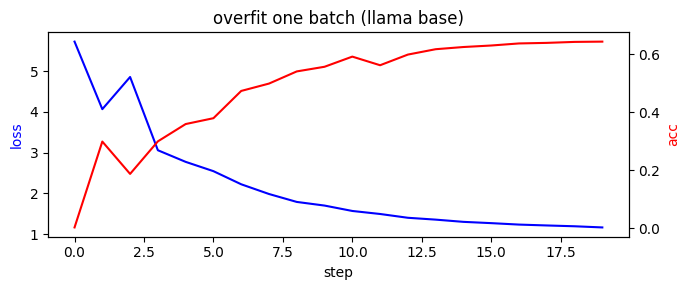

In [7]:
# Optional: simple loss curve
# Force the inline backend: .env.local sets MPLBACKEND=TkAgg (a GUI backend),
# which renders nothing under headless/nbconvert execution.
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

losses = [h[0] for h in history]
accs = [h[1] for h in history]
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(losses, 'b-', label='loss'); ax1.set_ylabel('loss', color='b'); ax1.set_xlabel('step')
ax2 = ax1.twinx(); ax2.plot(accs, 'r-', label='acc'); ax2.set_ylabel('acc', color='r')
plt.title('overfit one batch (llama base)'); plt.tight_layout(); plt.show()